In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/delhi_pm25_daily.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

df.head()

,date,pm25
0,2016-11-09 00:00:00+05:30,270.0
1,2016-11-10 00:00:00+05:30,259.0
2,2016-11-11 00:00:00+05:30,274.0
3,2016-11-12 00:00:00+05:30,238.0
4,2016-11-13 00:00:00+05:30,175.0


In [2]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate dates:", df["date"].duplicated().sum())

print("\nStatistics:")
print(df["pm25"].describe())

Shape: (3491, 2)

Data types:
date    datetime64[us, UTC+05:30]
pm25                      float64
dtype: object

Missing values:
date     0
pm25    92
dtype: int64

Duplicate dates: 0

Statistics:
count    3399.000000
mean      106.448311
std       122.947626
min        -7.260000
25%        39.400000
50%        71.300000
75%       141.000000
max      1990.000000
Name: pm25, dtype: float64


In [3]:
print("Zero values:", (df["pm25"] == 0).sum())
print("Negative values:", (df["pm25"] < 0).sum())

print("\nHighest PM2.5 values:")
print(df.nlargest(10, "pm25"))

Zero values: 0
Negative values: 5

Highest PM2.5 values:
                         date    pm25
425 2018-02-17 00:00:00+05:30  1990.0
426 2018-02-18 00:00:00+05:30  1990.0
427 2018-02-19 00:00:00+05:30  1990.0
622 2018-09-02 00:00:00+05:30  1990.0
635 2018-09-15 00:00:00+05:30  1990.0
778 2019-02-07 00:00:00+05:30  1540.0
779 2019-02-08 00:00:00+05:30  1450.0
320 2017-10-15 00:00:00+05:30  1120.0
428 2018-02-20 00:00:00+05:30  1080.0
344 2017-11-08 00:00:00+05:30   896.0


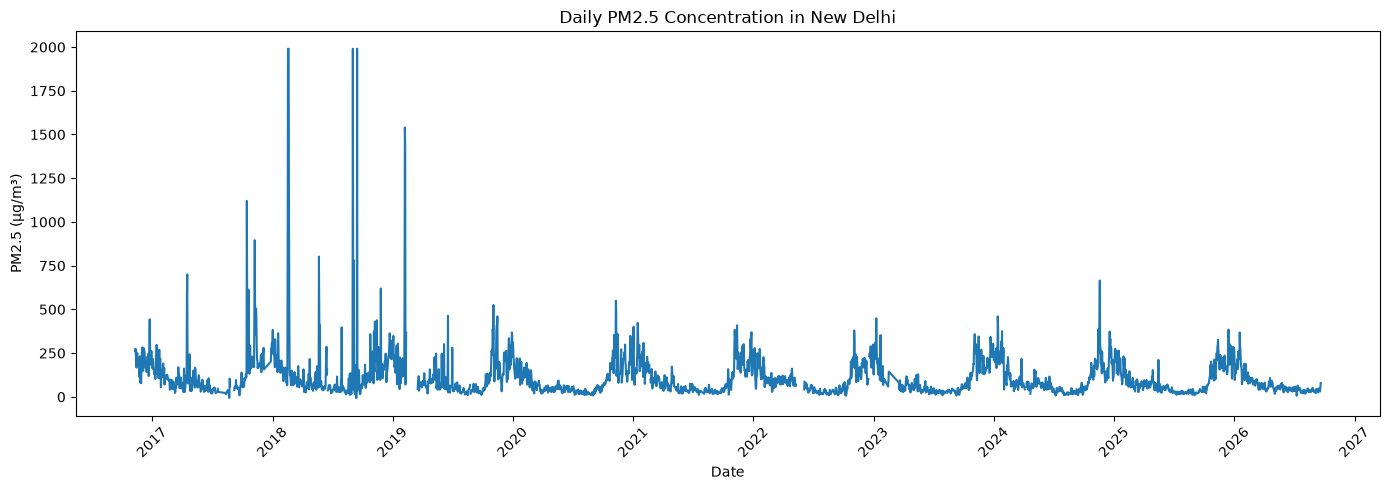

In [4]:
plt.figure(figsize=(14, 5))

plt.plot(df["date"], df["pm25"])

plt.title("Daily PM2.5 Concentration in New Delhi")
plt.xlabel("Date")
plt.ylabel("PM2.5 (µg/m³)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

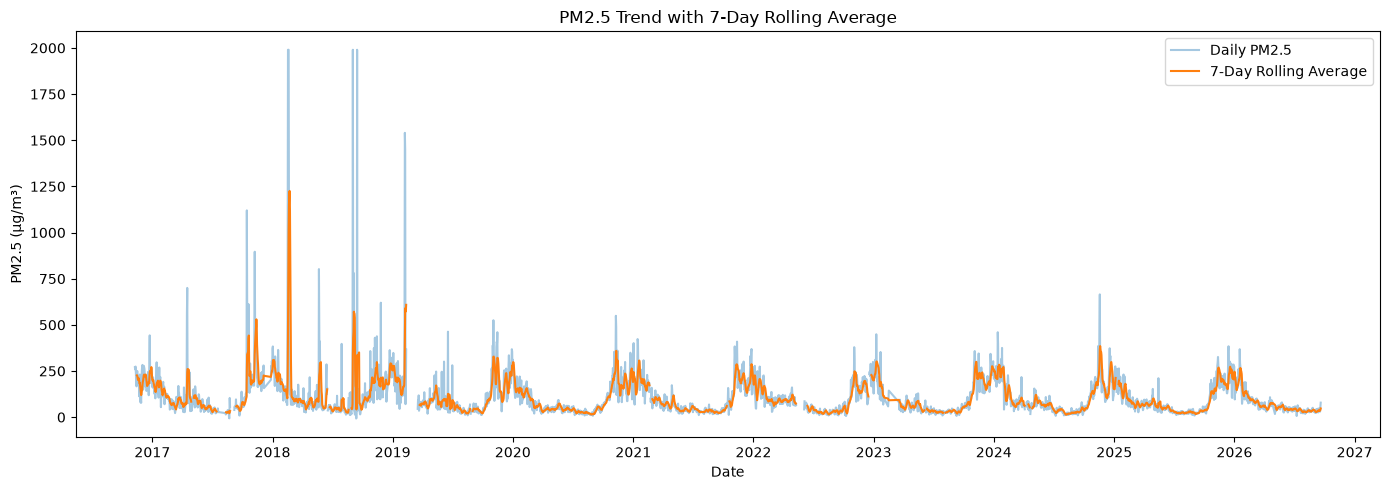

In [5]:
df["pm25_7day_avg"] = df["pm25"].rolling(7).mean()

plt.figure(figsize=(14, 5))

plt.plot(df["date"], df["pm25"], alpha=0.4, label="Daily PM2.5")
plt.plot(df["date"], df["pm25_7day_avg"], label="7-Day Rolling Average")

plt.title("PM2.5 Trend with 7-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.tight_layout()

plt.show()

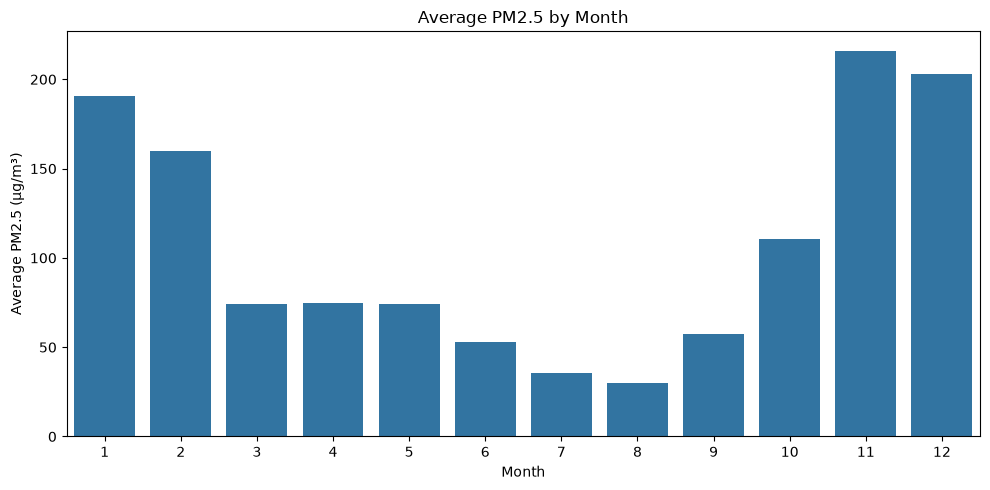

In [6]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

monthly = (
    df.groupby("month")["pm25"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(data=monthly, x="month", y="pm25")

plt.title("Average PM2.5 by Month")
plt.xlabel("Month")
plt.ylabel("Average PM2.5 (µg/m³)")
plt.tight_layout()

plt.show()

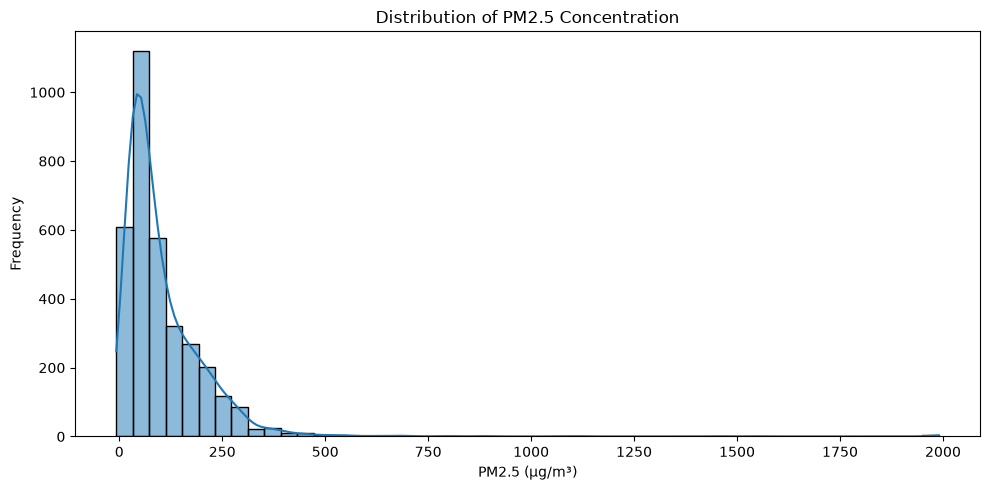

In [7]:
plt.figure(figsize=(10, 5))

sns.histplot(df["pm25"], bins=50, kde=True)

plt.title("Distribution of PM2.5 Concentration")
plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [8]:
top_days = df.nlargest(20, "pm25")[["date", "pm25"]]

top_days

,date,pm25
425,2018-02-17 00:00:00+05:30,1990.0
426,2018-02-18 00:00:00+05:30,1990.0
427,2018-02-19 00:00:00+05:30,1990.0
622,2018-09-02 00:00:00+05:30,1990.0
635,2018-09-15 00:00:00+05:30,1990.0
778,2019-02-07 00:00:00+05:30,1540.0
779,2019-02-08 00:00:00+05:30,1450.0
320,2017-10-15 00:00:00+05:30,1120.0
428,2018-02-20 00:00:00+05:30,1080.0
344,2017-11-08 00:00:00+05:30,896.0


In [9]:
df["target_pm25"] = df["pm25"].shift(-1)

df[["date", "pm25", "target_pm25"]].head(10)

,date,pm25,target_pm25
0,2016-11-09 00:00:00+05:30,270.0,259.0
1,2016-11-10 00:00:00+05:30,259.0,274.0
2,2016-11-11 00:00:00+05:30,274.0,238.0
3,2016-11-12 00:00:00+05:30,238.0,175.0
4,2016-11-13 00:00:00+05:30,175.0,167.0
5,2016-11-14 00:00:00+05:30,167.0,202.0
6,2016-11-15 00:00:00+05:30,202.0,250.0
7,2016-11-16 00:00:00+05:30,250.0,215.0
8,2016-11-17 00:00:00+05:30,215.0,195.0
9,2016-11-18 00:00:00+05:30,195.0,201.0


In [10]:
df["day_of_week"] = df["date"].dt.dayofweek
df["day_of_year"] = df["date"].dt.dayofyear
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)

df["lag_1"] = df["pm25"].shift(1)
df["lag_2"] = df["pm25"].shift(2)
df["lag_3"] = df["pm25"].shift(3)
df["lag_7"] = df["pm25"].shift(7)

df["rolling_3"] = df["pm25"].rolling(3).mean()
df["rolling_7"] = df["pm25"].rolling(7).mean()
df["rolling_14"] = df["pm25"].rolling(14).mean()

df.head(15)

,date,pm25,pm25_7day_avg,year,month,target_pm25,day_of_week,day_of_year,week_of_year,lag_1,lag_2,lag_3,lag_7,rolling_3,rolling_7,rolling_14
0,2016-11-09 00:00:00+05:30,270.0,NaN,2016,11,259.0,2,314,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-11-10 00:00:00+05:30,259.0,NaN,2016,11,274.0,3,315,45,270.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-11-11 00:00:00+05:30,274.0,NaN,2016,11,238.0,4,316,45,259.0,270.0,NaN,NaN,267.666667,NaN,NaN
3,2016-11-12 00:00:00+05:30,238.0,NaN,2016,11,175.0,5,317,45,274.0,259.0,270.0,NaN,257.000000,NaN,NaN
4,2016-11-13 00:00:00+05:30,175.0,NaN,2016,11,167.0,6,318,45,238.0,274.0,259.0,NaN,229.000000,NaN,NaN
5,2016-11-14 00:00:00+05:30,167.0,NaN,2016,11,202.0,0,319,46,175.0,238.0,274.0,NaN,193.333333,NaN,NaN
6,2016-11-15 00:00:00+05:30,202.0,226.428571,2016,11,250.0,1,320,46,167.0,175.0,238.0,NaN,181.333333,226.428571,NaN
7,2016-11-16 00:00:00+05:30,250.0,223.571429,2016,11,215.0,2,321,46,202.0,167.0,175.0,270.0,206.333333,223.571429,NaN
8,2016-11-17 00:00:00+05:30,215.0,217.285714,2016,11,195.0,3,322,46,250.0,202.0,167.0,259.0,222.333333,217.285714,NaN
9,2016-11-18 00:00:00+05:30,195.0,206.000000,2016,11,201.0,4,323,46,215.0,250.0,202.0,274.0,220.000000,206.000000,NaN


In [11]:
model_df = df.dropna().copy()

print("Final modelling dataset:", model_df.shape)
print(model_df.isna().sum())

Final modelling dataset: (3161, 16)
date             0
pm25             0
pm25_7day_avg    0
year             0
month            0
target_pm25      0
day_of_week      0
day_of_year      0
week_of_year     0
lag_1            0
lag_2            0
lag_3            0
lag_7            0
rolling_3        0
rolling_7        0
rolling_14       0
dtype: int64


In [12]:
model_df.to_csv(
    "../data/delhi_pm25_model_data.csv",
    index=False
)

print("Saved!")

Saved!


In [13]:
features = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7",
    "rolling_3",
    "rolling_7",
    "rolling_14",
    "day_of_week",
    "day_of_year",
    "week_of_year"
]

X = model_df[features]
y = model_df["target_pm25"]

In [14]:
split_index = int(len(model_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

print("\nTraining period:")
print(model_df["date"].iloc[:split_index].min())
print("to")
print(model_df["date"].iloc[:split_index].max())

print("\nTesting period:")
print(model_df["date"].iloc[split_index:].min())
print("to")
print(model_df["date"].iloc[-1])

Training: (2528, 10)
Testing: (633, 10)

Training period:
2016-11-22 00:00:00+05:30
to
2024-12-02 00:00:00+05:30

Testing period:
2024-12-03 00:00:00+05:30
to
2026-09-19 00:00:00+05:30


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R²:", linear_r2)

Linear Regression
MAE: 20.341323785199002
RMSE: 30.394816588552168
R²: 0.8140738788465042


In [17]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Random Forest
MAE: 22.16809943606129
RMSE: 36.74886465847108
R²: 0.7282126698724996


In [19]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost")
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R²:", xgb_r2)

XGBoost
MAE: 22.13601194845745
RMSE: 36.08286343066715
R²: 0.7379746293229139


In [20]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        linear_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R2": [
        linear_r2,
        rf_r2,
        xgb_r2
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,20.341324,30.394817,0.814074
1,Random Forest,22.168099,36.748865,0.728213
2,XGBoost,22.136012,36.082863,0.737975


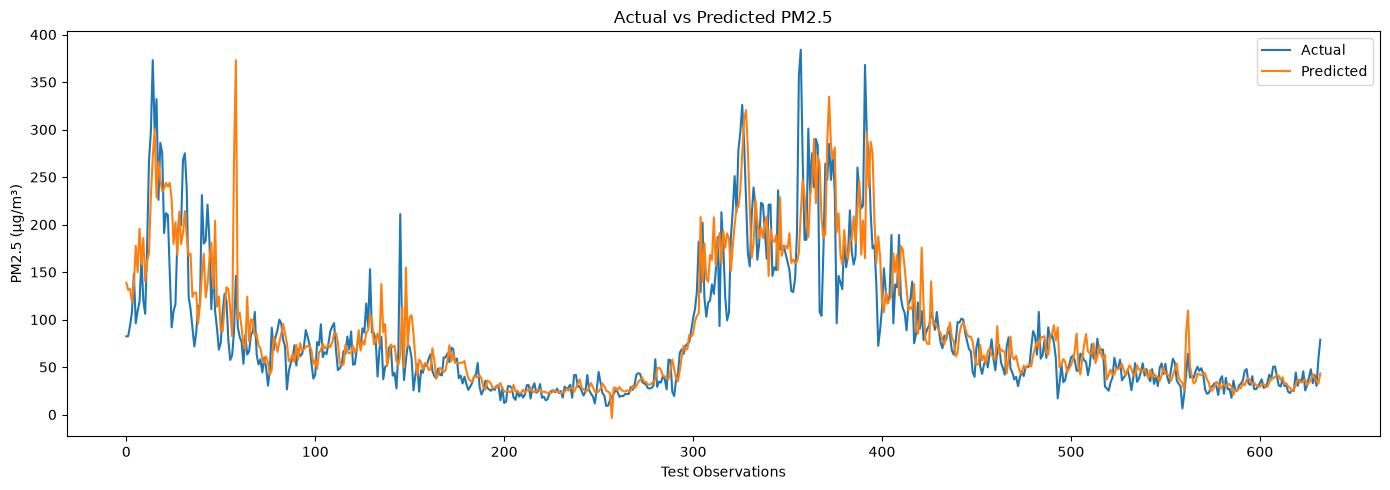

In [21]:
plt.figure(figsize=(14, 5))

plt.plot(y_test.values, label="Actual")
plt.plot(xgb_pred, label="Predicted")

plt.title("Actual vs Predicted PM2.5")
plt.xlabel("Test Observations")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()

plt.tight_layout()
plt.show()

In [22]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

importance

,Feature,Importance
4,rolling_3,0.292803
5,rolling_7,0.147876
8,day_of_year,0.104336
2,lag_3,0.100133
0,lag_1,0.078476
6,rolling_14,0.069795
1,lag_2,0.062905
9,week_of_year,0.061075
3,lag_7,0.058877
7,day_of_week,0.023724


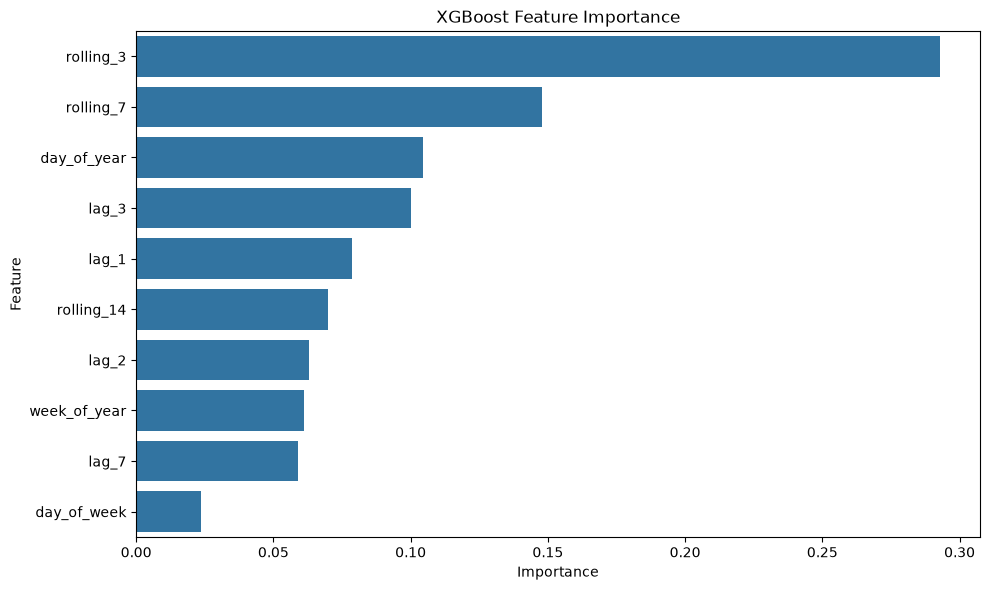

In [23]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("XGBoost Feature Importance")
plt.tight_layout()

plt.show()

In [24]:
import joblib

joblib.dump(
    xgb_model,
    "../models/xgboost_pm25_model.pkl"
)

print("Model saved!")

Model saved!


In [25]:
results.sort_values("RMSE")
print(results)

               Model        MAE       RMSE        R2
0  Linear Regression  20.341324  30.394817  0.814074
1      Random Forest  22.168099  36.748865  0.728213
2            XGBoost  22.136012  36.082863  0.737975


In [26]:
errors = pd.DataFrame({
    "actual": y_test.values,
    "predicted": xgb_pred
})

errors["error"] = errors["actual"] - errors["predicted"]
errors["absolute_error"] = abs(errors["error"])

errors.describe()

,actual,predicted,error,absolute_error
count,633.000000,633.000000,633.000000,633.000000
mean,84.390585,89.646118,-5.255539,22.136012
std,70.546040,68.994141,35.726303,28.517622
min,6.420000,-3.689435,-226.933807,0.028542
25%,35.500000,38.184814,-16.064235,5.335596
50%,59.500000,64.072830,-3.701019,12.331234
75%,107.000000,124.098480,7.696671,26.126833
max,384.000000,372.933807,203.496552,226.933807


In [27]:
errors.sort_values(
    "absolute_error",
    ascending=False
).head(10)

,actual,predicted,error,absolute_error
58,146.0,372.933807,-226.933807,226.933807
391,368.0,164.503448,203.496552,203.496552
356,357.0,170.317261,186.682739,186.682739
57,87.0,268.076782,-181.076782,181.076782
357,384.0,211.002655,172.997345,172.997345
367,108.0,263.984528,-155.984528,155.984528
145,211.0,62.152367,148.847633,148.847633
24,91.8,226.487198,-134.687198,134.687198
398,72.4,187.514786,-115.114786,115.114786
361,301.0,186.904160,114.095840,114.095840
